<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangGraph(Parallel_Executions).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langgraph

In [2]:
import operator
import time

from IPython.display import HTML, Image
from google.colab import userdata
from langchain_core.runnables import Runnable, RunnableConfig
from langgraph.checkpoint.base import BaseCheckpointSaver
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command,Interrupt, interrupt
from pathlib import Path
from typing import Annotated, TypedDict, List

def print_interrupts(interrupts: List[Interrupt]):
    for interrupt in interrupts:
        display(HTML(f'<div style="border: 1px dashed red; margin: 5px; padding: 10px; white-space: pre-wrap;">{interrupt.value}</div>'))

def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode = "wb") as file:
        file.write(runnable.get_graph().draw_mermaid_png())

    display(Image(output_png, format = "png"))

def explore_checkpoints(checkpoint_saver: BaseCheckpointSaver, config: RunnableConfig):
    checkpoints = list(checkpoint_saver.list(config))
    print(f"There are {len(checkpoints)} checkpoints in total:")
    for checkpoint in reversed(checkpoints):
        print(checkpoint)

def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig):
    state_history = list(compiled_state_graph.get_state_history(config))

    for snapshot in reversed(state_history):
        print(f"Step: {snapshot.metadata['step']}")
        print("Current state:")
        print(snapshot.values)
        print(f"Next: {snapshot.next}")
        print()

In [19]:
checkpointer = InMemorySaver()

def merge_findings(a: dict[str, str], b: dict[str, str]) -> dict[str, str]: # custom reducer
    # `b` overwrites `a` in case of conflicts.
    # This fragment can be modified to raise an error instead.
    return { **a, **b } # взимаме записите от първия речник и към тях добавяме, overwriteваме записите от втория

class ResearchState(TypedDict):
    topic: str
    findings: Annotated[dict[str, str], merge_findings] # речник - ключа да е източника на инф, а value - описание на търсената тема
    verification_requests: Annotated[set[str], operator.or_]
    verified: Annotated[set[str], operator.or_]
    blocked: Annotated[set[str], operator.or_]
    summary: str # ще бъде попълнен от merge node

In [20]:
def wikipedia(state: ResearchState):
    print("[WIKIPEDIA] node is executing")
    time.sleep(2)

    return { "findings": { "wikipedia": f"[WIKIPEDIA] { state['topic'] }" }, "verification_requests": {"wikipedia"} } # връщаме нотация която трябва да бъде обединена с reducer

# през state като -  state['topic'] ще потърси информация

def news(state: ResearchState):
    print("[LIVE NEWS] node is executing")
    time.sleep(2)

    return { "findings": { "news": f"[LIVE NEWS] Sensational! { state['topic'] }" }, "verification_requests": {"news"} }

def arxiv(state: ResearchState):
    print("[ARXIV] node is executing")
    time.sleep(2)

    return { "findings": { "arxiv": f"[ARXIV] the theoretical hyperchaotic entanglement of relativities related to  \"{ state['topic'] }\"" } }

def verify(state: ResearchState):
    current_verified = state.get('verfied', set())
    current_blocked = state.get('blocked', set())

    new_verified = set()
    new_blocked = set()

    for request in state.get('verification_requests', set()):
      # If request is already processed -> continue
        if request in current_verified or request in current_blocked:
            continue

      # If not, decide whether to verify or block it
        if len(request) % 2 == 0:
            new_verified.add(request)
        else:
            new_blocked.add(request)

    return {"verified": new_verified, "blocked": new_blocked}


def _annotate_findings(finding_key: str, state: ResearchState):
    if finding_key in state.get('verified', set()):
        return " (verified)"
    elif finding_key in state.get('blocked', set()):
        return " (blocked)"
    else:
        return ""

# merge node ще бъде изпълнен като приключат - news,arxiv, wikipedia. Интересува се само и единствено от инф на state
def merge(state: ResearchState):
    if len(state.get('verification_requests', set())) > len(state.get('verified', set())) + len(state.get('blocked', set())):
        return
    bullets = "\n".join(f" - {finding}{_annotate_findings(key,state)}" for key, finding in state.get('findings', {}).items()) # обхожда всички findings
    return { "summary": f"Summary:\n{bullets}" }

In [21]:
graph_builder = StateGraph(ResearchState)
graph_builder.add_node("wikipedia", wikipedia)
graph_builder.add_node("news", news)
graph_builder.add_node("arxiv", arxiv)
graph_builder.add_node("verify", verify)
graph_builder.add_node("merge", merge)

## NOTE: The three nodes ("wikipedia", "news", "arxiv") will be executed in parallel, then two of them will be verified and only after that they will be merged together.
graph_builder.add_edge(START, "wikipedia")
graph_builder.add_edge(START, "news")
graph_builder.add_edge(START, "arxiv")

graph_builder.add_edge("wikipedia", "verify")
graph_builder.add_edge("news", "verify")
graph_builder.add_edge("verify", "merge")
graph_builder.add_edge("arxiv", "merge")

graph_builder.add_edge("merge", END)

# A checkpointer is necessary in order to resume the execution later.
graph = graph_builder.compile(checkpointer = checkpointer)

## Очакваното поведение е:
  - обръщаме се като кажем темата към която се интересуваме, системата е ResearchAgent. Казваме темата и системата възлага задача на arxiv, news, wikipedia - паралелно ще бъдат изпълнени, паралелно ще симулираме в случая търсене на инф в трите отделни нодове и когато и трите са готови ще изпълнем merge node.

  - функциите зад самите нодове трябва да са изчистени - as pure as possible . единствените им зависимости трябва да бъдат по input парамерите - runtime(по който да достъпим store, да инжектираме нещо в контекста), текущият state

  - самият стейт да обоготим, така че merge node да достъпва стойностите от arxiv, news, wikipedia

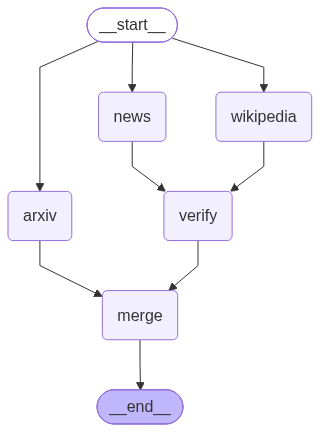

In [12]:
display_graph(graph, Path('/content/graph.png'))

In [22]:
thread1_config = { "configurable": { "thread_id": "thread_1" } }
thread1_result = graph.invoke(
    input={
        "topic": "Maximum snooker break"
    },
    config=thread1_config
)

[ARXIV] node is executing
[WIKIPEDIA] node is executing
[LIVE NEWS] node is executing


In [23]:
print(thread1_result['summary'])

Summary:
 - [ARXIV] the theoretical hyperchaotic entanglement of relativities related to  "Maximum snooker break"
 - [LIVE NEWS] Sensational! Maximum snooker break (verified)
 - [WIKIPEDIA] Maximum snooker break (blocked)


In [24]:
thread1_result

{'topic': 'Maximum snooker break',
 'findings': {'arxiv': '[ARXIV] the theoretical hyperchaotic entanglement of relativities related to  "Maximum snooker break"',
  'news': '[LIVE NEWS] Sensational! Maximum snooker break',
  'wikipedia': '[WIKIPEDIA] Maximum snooker break'},
 'verification_requests': {'news', 'wikipedia'},
 'verified': {'news'},
 'blocked': {'wikipedia'},
 'summary': 'Summary:\n - [ARXIV] the theoretical hyperchaotic entanglement of relativities related to  "Maximum snooker break"\n - [LIVE NEWS] Sensational! Maximum snooker break (verified)\n - [WIKIPEDIA] Maximum snooker break (blocked)'}

In [25]:
explore_checkpoints(checkpointer, thread1_config)

There are 5 checkpoints in total:
CheckpointTuple(config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a8519-f06c-6127-bfff-4f6fd76545f1'}}, checkpoint={'v': 4, 'ts': '2026-09-04T11:13:13.903327+00:00', 'id': '1f1a8519-f06c-6127-bfff-4f6fd76545f1', 'channel_versions': {'__start__': '00000000000000000000000000000001.0.07131643828156276'}, 'versions_seen': {'__input__': {}}, 'updated_channels': ['__start__'], 'channel_values': {'__start__': {'topic': 'Maximum snooker break'}}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, parent_config=None, pending_writes=[('e14ca4bf-1dc4-336a-df66-588195b50d89', 'topic', 'Maximum snooker break'), ('e14ca4bf-1dc4-336a-df66-588195b50d89', 'branch:to:arxiv', None), ('e14ca4bf-1dc4-336a-df66-588195b50d89', 'branch:to:news', None), ('e14ca4bf-1dc4-336a-df66-588195b50d89', 'branch:to:wikipedia', None)])
CheckpointTuple(config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1

In [26]:
explore_state_history(graph, thread1_config)

Step: -1
Current state:
{'findings': {}, 'verification_requests': set(), 'verified': set(), 'blocked': set()}
Next: ('__start__',)

Step: 0
Current state:
{'topic': 'Maximum snooker break', 'findings': {}, 'verification_requests': set(), 'verified': set(), 'blocked': set()}
Next: ('wikipedia', 'news', 'arxiv')

Step: 1
Current state:
{'topic': 'Maximum snooker break', 'findings': {'arxiv': '[ARXIV] the theoretical hyperchaotic entanglement of relativities related to  "Maximum snooker break"', 'news': '[LIVE NEWS] Sensational! Maximum snooker break', 'wikipedia': '[WIKIPEDIA] Maximum snooker break'}, 'verification_requests': {'news', 'wikipedia'}, 'verified': set(), 'blocked': set()}
Next: ('verify', 'merge')

Step: 2
Current state:
{'topic': 'Maximum snooker break', 'findings': {'arxiv': '[ARXIV] the theoretical hyperchaotic entanglement of relativities related to  "Maximum snooker break"', 'news': '[LIVE NEWS] Sensational! Maximum snooker break', 'wikipedia': '[WIKIPEDIA] Maximum snoo